In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

df_sales = pd.read_csv('../data/processed/online_retail_cleaned.csv')
df_cancellations = pd.read_csv('../data/processed/cancellations.csv')

df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])
df_cancellations['InvoiceDate'] = pd.to_datetime(df_cancellations['InvoiceDate'])

print(df_sales.shape)
df_sales.head()

(1003452, 11)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,Revenue,Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,Christmas & Seasonal
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,Home Decor & Lighting
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,Home Decor & Lighting
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,Home Decor & Lighting
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,Storage & Boxes


## RQ1 — Revenue Drivers (Time, Category, Country)

In [2]:
total_revenue = df_sales['Revenue'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £19,645,995.71


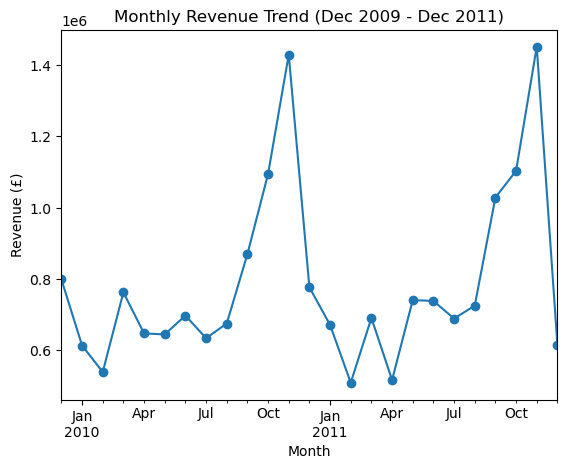

In [3]:
#Revenue over time (monthly trend)
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_sales.groupby('YearMonth')['Revenue'].sum()

monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend (Dec 2009 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.show()

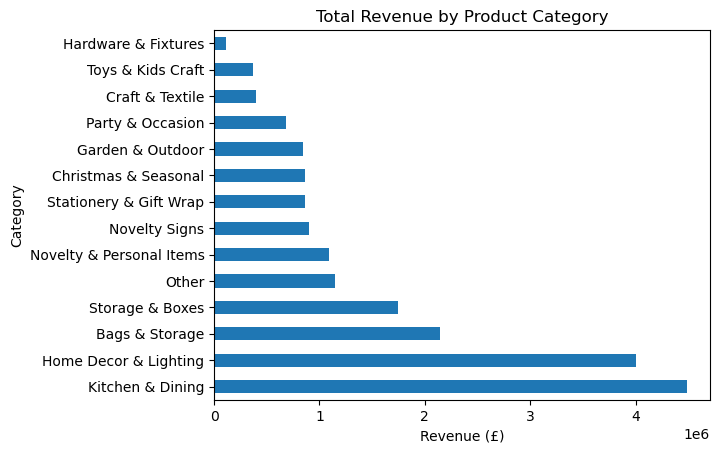

In [4]:
# Revenue by category
category_revenue = df_sales.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

category_revenue.plot(kind='barh')
plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue (£)')
plt.ylabel('Category')
plt.show()

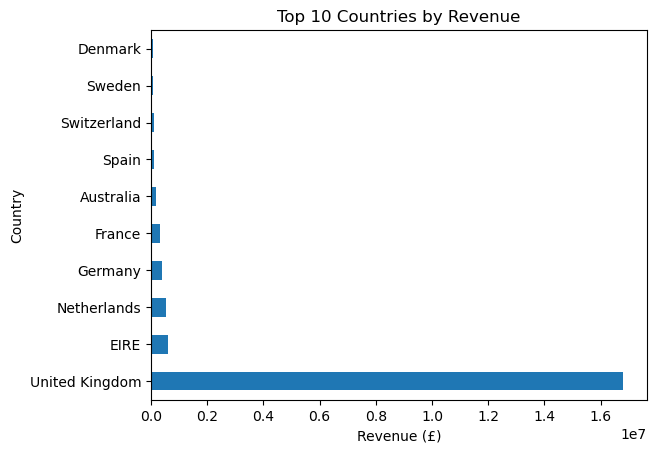

In [5]:
# Revenue by country
country_revenue = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_revenue.plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.show()

In [6]:
uk_pct = df_sales[df_sales['Country'] == 'United Kingdom']['Revenue'].sum() / total_revenue * 100
print(f"UK share of revenue: {uk_pct: .2f}%")

UK share of revenue:  85.53%


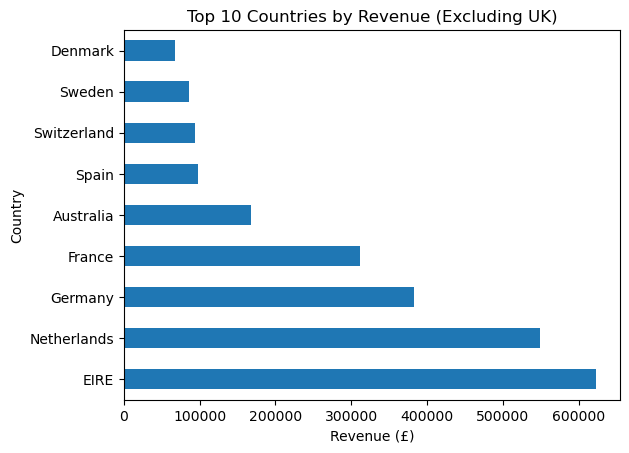

In [7]:
country_revenue_no_uk = country_revenue[country_revenue.index != 'United Kingdom']

country_revenue_no_uk.head(10).plot(kind='barh')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.show()

In [8]:
intl_total = df_sales[df_sales['Country'] != 'United Kingdom']['Revenue'].sum()
country_revenue_pct = (country_revenue_no_uk / intl_total * 100).round(2)
print(country_revenue_pct)

Country
EIRE           21.93
Netherlands    19.34
Germany        13.48
France         10.94
Australia       5.90
Spain           3.44
Switzerland     3.31
Sweden          3.04
Denmark         2.37
Name: Revenue, dtype: float64


##Nolan Retail CO. generated £19.6M in total revenue over the two-year period, with strong seasonality: revenue peaks each November (likely driven by pre-Christmas demand), rising over 2.5 times from its typical off-season low around February. Kitchen & Dining and Home Decor & Lighting are the two leading categories, together accounting for roughly 43% of total revenue, while Hardware & Fixtures is the weakest performer. The business is heavily UK- dependent, with the United Kingdom generating 85.53% of total revenue; EIRE, the Netherlands and Germany are the largest international markets but remain small relative to the domestic base, suggesting international growth is a real, currently underdeveloped opportunity.

## RQ2 -Customer Value & Concentration

In [9]:
df_customer = pd.read_csv('../data/processed/online_retail_with_customer.csv')
df_customer['InvoiceDate'] = pd.to_datetime(df_customer['InvoiceDate'])
print(df_customer.shape)

(776606, 11)


In [10]:
#Revenue per customer
customer_revenue = df_customer.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.describe()

count      5852.000000
mean       2916.747904
std       14307.046290
min           2.950000
25%         339.575000
50%         856.020000
75%        2241.030000
max      580987.040000
Name: Revenue, dtype: float64

In [11]:
customer_revenue.sort_values(ascending=False).head(10)

Customer ID
18102    580987.04
14646    526751.52
14156    303069.88
14911    272252.79
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64

In [12]:
top10_total = customer_revenue.sort_values(ascending=False).head(10).sum()
top10_pct = top10_total / customer_revenue.sum() * 100
print(f"Top 10 customers generated £{top10_total:,.2f} ({top10_pct:.2f}% of total customer-attributed revenue)")

Top 10 customers generated £2,755,267.68 (16.14% of total customer-attributed revenue)


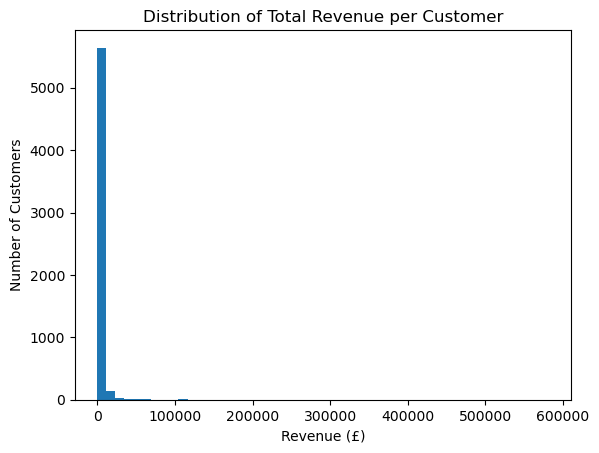

In [13]:
customer_revenue.plot(kind='hist', bins=50)
plt.title('Distribution of Total Revenue per Customer')
plt.xlabel('Revenue (£)')
plt.ylabel('Number of Customers')
plt.show()

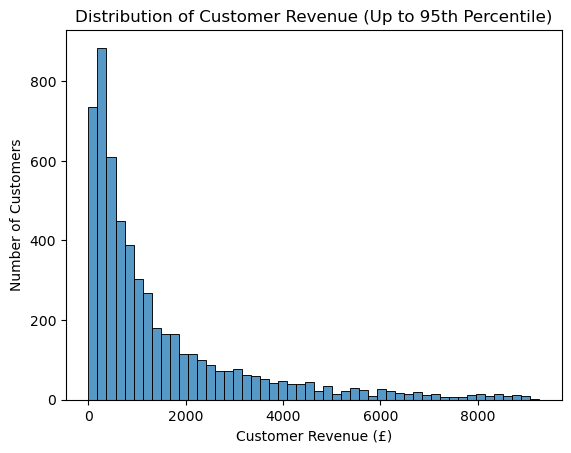

In [14]:
upper_limit = customer_revenue.quantile(0.95)
plt.figure()
sns.histplot(customer_revenue[customer_revenue <= upper_limit],bins=50)
plt.title("Distribution of Customer Revenue (Up to 95th Percentile)")
plt.xlabel("Customer Revenue (£)")
plt.ylabel("Number of Customers")
plt.show()

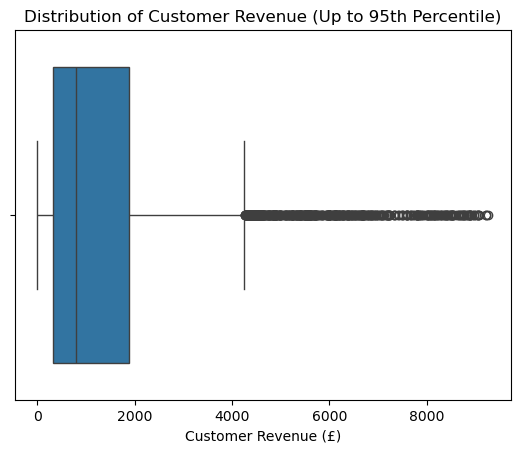

In [15]:
plt.figure()
sns.boxplot(x=customer_revenue[customer_revenue <= upper_limit])
plt.title("Distribution of Customer Revenue (Up to 95th Percentile)")
plt.xlabel("Customer Revenue (£)")
plt.show()

The boxplot of customer revenue (capped at the 95th percentile) still shows a large number of points flagged as statistical outliers beyond ~£4,000 — even after excluding the top 5% of highest spenders. This indicates that revenue concentration in Nova Retail Co.'s customer base isn't limited to a handful of extreme accounts; there is a substantial, persistent tail of above-average spenders extending well beyond the "typical" customer range.